# Tutorial: Graph Coloring with (quantum) column generation algorithm

An end-to-end walkthrough of the column-generation pipeline for vertex
coloring, where the **pricing sub-problem** (max-weighted independent set)
is solved on QCi's **Dirac-3 entropy computer** via the
Motzkin-Straus continuous relaxation.

This notebook mirrors the structure of `tutorial_5_graph_coloring_column_generation.ipynb`
but the quantum part uses Dirac-3 (continuous-relaxation hardware) rather
than a neutral-atom sampler. The rest of the story is unchanged: classical
column generation first, then the same algorithm with a quantum PSP, then
an application to antenna frequency assignment and a 3-way comparison
against direct MILP.

## Reduced Master Problem (RMP) and Column Generation Algorithms

The Reduced Master Problem is an algorithm introduced by Wesley da Silva Coelho
et al. ([arXiv:2301.02637](https://arxiv.org/abs/2301.02637)) as a
quantum-enhanced column generation method.

Column generation is an iterative optimization methodology designed to
tackle linear programs with an overwhelmingly large number of variables
(or *columns*). For minimum vertex coloring, the natural LP relaxation has
**one column per independent set** — exponentially many. Column generation
sidesteps the size issue: start with a small column pool, repeatedly solve
a **Restricted Master Problem (RMP)** on that pool, and use the RMP's
**dual variables** to drive a **Pricing Sub-Problem (PSP)** that searches
for a profitable new column to add. The PSP for vertex coloring is exactly
the **Maximum Weighted Independent Set** problem on the input graph, with
the RMP duals as vertex weights.

The interaction is cyclical: solve RMP → extract duals → solve PSP → if a
profitable column is found, add it; otherwise we've reached LP optimality.
A final integer solve on the full pool gives the chromatic number χ.

## Classical Column Generation Solver

Let's first demonstrate the algorithm and workflow with fully classical
solvers — `scipy.linprog` for the RMP and `scipy.milp` for the PSP.

In [1]:
import numpy as np
from scipy.optimize import linprog, milp, OptimizeWarning, LinearConstraint, Bounds
from scipy.sparse import lil_matrix
import warnings
import networkx as nx
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=OptimizeWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


In [2]:
def solve_mvcp_column_generation(G, graph_name="Graph"):
    """
    Solves the Minimum Vertex Coloring Problem (MVCP) using classical column generation.
    """
    num_vertices = G.number_of_nodes()
    original_nodes = sorted(list(G.nodes()))
    node_to_idx = {node: i for i, node in enumerate(original_nodes)}
    mapped_edges = [(node_to_idx[u], node_to_idx[v]) for u, v in G.edges()]
    edges = mapped_edges

    print(f"Solving MVCP for a graph with {num_vertices} vertices and {len(edges)} edges.")

    # 2. Initialization with singleton independent sets
    current_columns = [frozenset([i]) for i in range(num_vertices)]
    known_column_signatures = {tuple(sorted(list(s))) for s in current_columns}
    print(f"Initial columns (singleton independent sets): {current_columns}\n")

    max_iterations = 20
    iteration = 0
    tolerance = 1e-6

    while iteration < max_iterations:
        iteration += 1
        print(f"--- Iteration {iteration} ---")

        # 3. Solve Reduced Master Problem (RMP)
        num_columns = len(current_columns)
        A = lil_matrix((num_vertices, num_columns))
        for s_idx, independent_set in enumerate(current_columns):
            for vertex in independent_set:
                A[vertex, s_idx] = 1
        A = A.tocsc()
        b = np.ones(num_vertices)
        c = np.ones(num_columns)
        bounds = [(0, 1) for _ in range(num_columns)]

        print(f"  Solving RMP with {num_columns} columns...")
        rmp_result = linprog(c, A_eq=A, b_eq=b, bounds=bounds, method='highs')
        if not rmp_result.success:
            print(f"  RMP failed: {rmp_result.message}")
            break
        print(f"  RMP Objective (LP relaxed): {rmp_result.fun:.4f}")

        dual_vars = rmp_result.eqlin.marginals
        print(f"  Dual variables: {np.round(dual_vars, 3)}")

        # 4. Solve Pricing Subproblem (MWIS) via exact MILP
        print(f"  Solving PSP (MWIS) classically...")
        c_psp = -np.array(dual_vars)
        integrality_psp = np.ones(num_vertices, dtype=int)
        bounds_psp = ([0] * num_vertices, [1] * num_vertices)
        num_edges = len(edges)
        A_ub_psp = lil_matrix((num_edges, num_vertices), dtype=float)
        for i, edge in enumerate(edges):
            A_ub_psp[i, edge[0]] = 1
            A_ub_psp[i, edge[1]] = 1
        b_ub_psp = np.ones(num_edges)
        psp_constraints = [LinearConstraint(A_ub_psp.toarray(), -np.inf, b_ub_psp)]
        psp_result = milp(c=c_psp, constraints=psp_constraints, integrality=integrality_psp, bounds=bounds_psp)
        if not psp_result.success:
            print(f"  PSP failed: {psp_result.message}")
            break

        new_independent_set_indices = [v for v, val in enumerate(psp_result.x) if val > 0.5]
        new_independent_set = set(new_independent_set_indices)
        psp_objective = -psp_result.fun
        print(f"  PSP found IS: {new_independent_set} (objective = {psp_objective:.4f})")

        reduced_cost = 1 - psp_objective
        if reduced_cost >= -tolerance:
            print(f"\n  No more profitable columns (PSP objective {psp_objective:.4f} <= 1). Stopping.\n")
            break

        new_column_signature = tuple(sorted(list(new_independent_set)))
        if new_column_signature not in known_column_signatures:
            current_columns.append(frozenset(new_independent_set))
            known_column_signatures.add(new_column_signature)
            print(f"  Added column. Total: {len(current_columns)}")
        else:
            print(f"  Column already exists. Stopping.")
            break

    # 5. Final integer master
    print("\n--- Solving Final RMP as Integer Linear Program ---\n")
    final_num_columns = len(current_columns)
    final_A = lil_matrix((num_vertices, final_num_columns))
    for s_idx, independent_set in enumerate(current_columns):
        for vertex in independent_set:
            final_A[vertex, s_idx] = 1
    final_A = final_A.tocsc()
    final_c = np.ones(final_num_columns)
    final_b = np.ones(num_vertices)
    integrality = np.ones(final_num_columns, dtype=int)

    constraints_obj = LinearConstraint(final_A, final_b, final_b)
    bounds_obj = Bounds(lb=0, ub=1)
    final_rmp_result = milp(c=final_c, integrality=integrality,
                            constraints=constraints_obj, bounds=bounds_obj)

    coloring_solution_list = []
    if final_rmp_result.success:
        num_colors = int(round(final_rmp_result.fun))
        print(f"Minimum number of colors: {num_colors}")
        for i, y_val in enumerate(final_rmp_result.x):
            if y_val > 0.5:
                original_color_set = {original_nodes[v] for v in current_columns[i]}
                coloring_solution_list.append(frozenset(original_color_set))
                print(f"  Color {len(coloring_solution_list)}: {sorted(original_color_set)}")
    else:
        print(f"Final RMP failed: {final_rmp_result.message}")

    return final_rmp_result, current_columns, coloring_solution_list


Some plotting utilities.

In [3]:
def plot_graph(graph, title="Graph", node_colors=None, pos=None):
    """Plot a graph with optional per-node colors."""
    if pos is None:
        pos = nx.spring_layout(graph, seed=42)
    plt.figure(figsize=(8, 6))
    if node_colors:
        if isinstance(node_colors, dict):
            color_map = [node_colors.get(node, 'lightgray') for node in graph.nodes()]
        else:
            color_map = node_colors
        nx.draw(graph, pos, with_labels=True, node_color=color_map,
                node_size=700, font_size=10, font_weight='bold', edge_color='gray')
    else:
        nx.draw(graph, pos, with_labels=True, node_color='skyblue',
                node_size=700, font_size=10, font_weight='bold', edge_color='gray')
    plt.title(title)
    plt.show()


def plot_classical_cg_solution(G, final_result, coloring_solution_list, num_colors,
                               graph_name="Graph"):
    """Plot the final coloring from a CG run."""
    graph_layout = nx.spring_layout(G, seed=42)
    if final_result and final_result.success:
        final_coloring_map = {}
        palette = ['red', 'green', 'blue', 'yellow', 'purple', 'orange', 'cyan',
                   'magenta', 'lime', 'pink', 'teal', 'brown', 'gold', 'salmon']
        for k, color_set in enumerate(coloring_solution_list):
            for node in color_set:
                final_coloring_map[node] = palette[k % len(palette)]
        plot_graph(G, title=f"{graph_name} — Final Coloring: {num_colors} colors",
                   node_colors=final_coloring_map, pos=graph_layout)
    else:
        plot_graph(G, title=f"{graph_name} — Solution Failed", pos=graph_layout)


### Examples

Running classical MVCP solver for Graph 1 (5-vertex)...
Solving MVCP for a graph with 5 vertices and 6 edges.
Initial columns (singleton independent sets): [frozenset({0}), frozenset({1}), frozenset({2}), frozenset({3}), frozenset({4})]

--- Iteration 1 ---
  Solving RMP with 5 columns...
  RMP Objective (LP relaxed): 5.0000
  Dual variables: [1. 1. 1. 1. 1.]
  Solving PSP (MWIS) classically...
  PSP found IS: {0, 3} (objective = 2.0000)
  Added column. Total: 6
--- Iteration 2 ---
  Solving RMP with 6 columns...
  RMP Objective (LP relaxed): 4.0000
  Dual variables: [ 1.  1.  1. -0.  1.]
  Solving PSP (MWIS) classically...
  PSP found IS: {1, 4} (objective = 2.0000)
  Added column. Total: 7
--- Iteration 3 ---
  Solving RMP with 7 columns...
  RMP Objective (LP relaxed): 3.0000
  Dual variables: [ 1.  1.  1. -0. -0.]
  Solving PSP (MWIS) classically...
  PSP found IS: {2} (objective = 1.0000)

  No more profitable columns (PSP objective 1.0000 <= 1). Stopping.


--- Solving Final RMP 

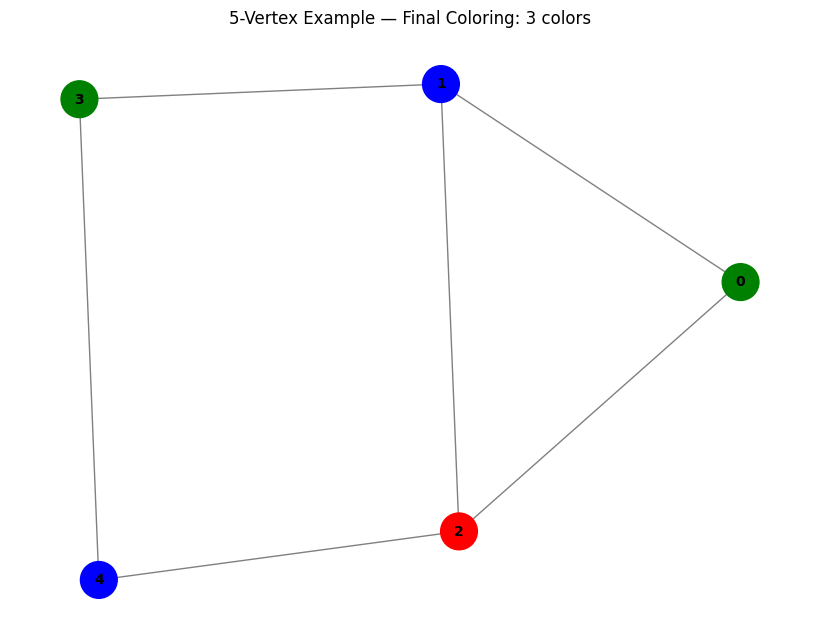

In [4]:
# Example 1: The 5-vertex graph from the paper
G1 = nx.Graph()
G1.add_nodes_from(range(5))
G1.add_edges_from([(0, 1), (0, 2), (1, 2), (1, 3), (2, 4), (3, 4)])
print("Running classical MVCP solver for Graph 1 (5-vertex)...")
result1, columns1, classical_coloring1 = solve_mvcp_column_generation(G1, graph_name="5-Vertex")

print("\n--- Summary for Graph 1 ---")
if result1 and result1.success:
    print(f"Final number of colors: {int(round(result1.fun))}")
    print(f"Total columns generated: {len(columns1)}")
    plot_classical_cg_solution(G1, result1, classical_coloring1,
                               int(round(result1.fun)), "5-Vertex Example")


Running classical MVCP solver for ER(9, 0.4)...
Solving MVCP for a graph with 9 vertices and 16 edges.
Initial columns (singleton independent sets): [frozenset({0}), frozenset({1}), frozenset({2}), frozenset({3}), frozenset({4}), frozenset({5}), frozenset({6}), frozenset({7}), frozenset({8})]

--- Iteration 1 ---
  Solving RMP with 9 columns...
  RMP Objective (LP relaxed): 9.0000
  Dual variables: [1. 1. 1. 1. 1. 1. 1. 1. 1.]
  Solving PSP (MWIS) classically...
  PSP found IS: {8, 1, 2, 5} (objective = 4.0000)
  Added column. Total: 10
--- Iteration 2 ---
  Solving RMP with 10 columns...
  RMP Objective (LP relaxed): 6.0000
  Dual variables: [ 1.  1.  1.  1.  1.  1.  1.  1. -2.]
  Solving PSP (MWIS) classically...
  PSP found IS: {0, 5, 6, 7} (objective = 4.0000)
  Added column. Total: 11
--- Iteration 3 ---
  Solving RMP with 11 columns...
  RMP Objective (LP relaxed): 6.0000
  Dual variables: [ 1.  1.  1.  1.  1. -2.  1.  1.  1.]
  Solving PSP (MWIS) classically...
  PSP found IS: {

  PSP found IS: {3, 4, 7} (objective = 1.6667)
  Added column. Total: 18
--- Iteration 10 ---
  Solving RMP with 18 columns...
  RMP Objective (LP relaxed): 3.3333
  Dual variables: [ 0.667  0.333  0.333  0.667  0.333 -0.333  0.667 -0.     0.667]
  Solving PSP (MWIS) classically...
  PSP found IS: {8, 1, 2} (objective = 1.3333)
  Added column. Total: 19
--- Iteration 11 ---
  Solving RMP with 19 columns...
  RMP Objective (LP relaxed): 3.0000
  Dual variables: [-0. -0. -0.  1. -0. -0.  1. -0.  1.]
  Solving PSP (MWIS) classically...
  PSP found IS: {8} (objective = 1.0000)

  No more profitable columns (PSP objective 1.0000 <= 1). Stopping.


--- Solving Final RMP as Integer Linear Program ---

Minimum number of colors: 3
  Color 1: [0, 5, 6, 7]
  Color 2: [3, 4]
  Color 3: [1, 2, 8]

--- Summary for Graph 2 ---
Final number of colors: 3
Total columns generated: 19


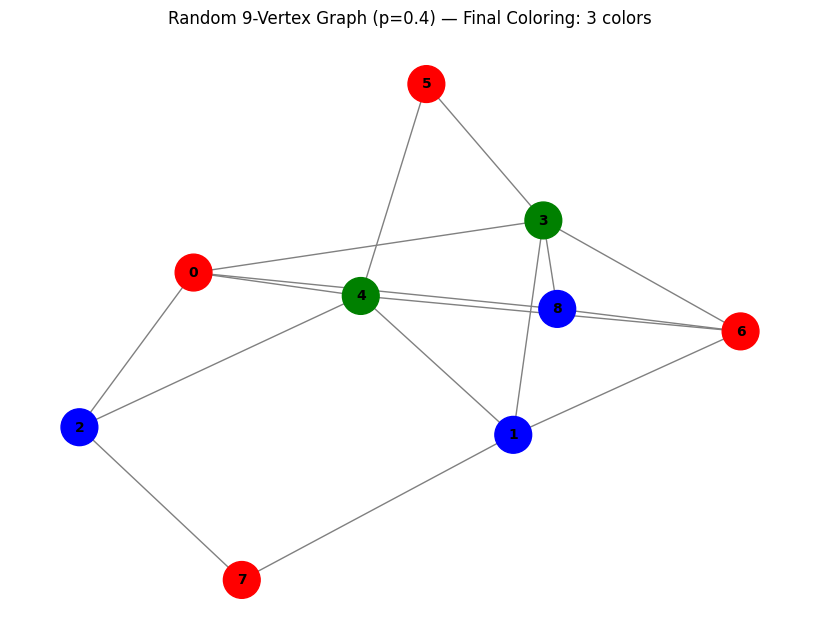

In [5]:
# Example 2: Random Graph (Erdos-Renyi)
num_random_nodes = 9
prob_edge = 0.4
seed_random = 42
G2 = nx.gnp_random_graph(num_random_nodes, prob_edge, seed=seed_random)

print(f"Running classical MVCP solver for ER({num_random_nodes}, {prob_edge})...")
result2, columns2, classical_coloring2 = solve_mvcp_column_generation(
    G2, graph_name=f"ER({num_random_nodes}, {prob_edge})")

print("\n--- Summary for Graph 2 ---")
if result2 and result2.success:
    print(f"Final number of colors: {int(round(result2.fun))}")
    print(f"Total columns generated: {len(columns2)}")
    plot_classical_cg_solution(G2, result2, classical_coloring2,
                               int(round(result2.fun)),
                               f"Random {num_random_nodes}-Vertex Graph (p={prob_edge})")


## Quantum Column Generation Solver

**Great! But how could a quantum computer help?**

#### QCi's Dirac-3 entropy computer

Dirac-3 is an **entropy quantum computer**: a photonic device that uses a
parametric resonance loop to minimise a quadratic objective $\tfrac12 x^\top J x + C^\top x$
over the continuous simplex $\sum_i x_i = R,\; x_i \ge 0$ in physical
hardware. A single shot returns a sample $x^* \in \mathbb{R}^n$ near a local
optimum, and a single call returns up to 100 such samples in parallel.

#### The Motzkin-Straus connection

For an undirected graph $G$ on $n$ vertices with adjacency $A$ and
stability number $\alpha(G)$, the **Motzkin-Straus theorem** (1965) states

$$\frac{1}{2}\!\left(1 - \frac{1}{\alpha(G)}\right) = \max_{\substack{\mathbf{1}^\top x = 1 \\ x \ge 0}} \tfrac12\, x^\top A\, x.$$

Maximisers are supported on **maximum cliques** in $G$. Equivalently,
running Motzkin-Straus on the **complement graph** $\bar G$ recovers
**maximum independent sets** in $G$ — exactly the object our pricing
sub-problem needs.

For the dual-weighted PSP we use **Gibbons' weighted Motzkin-Straus**
formulation (with weight matrix $B$ built from dual variables) and submit
$\min \tfrac12 x^\top B x$ on the simplex to Dirac-3. Support-thresholding
the returned solution vectors yields candidate independent sets, and a
1-swap local-search refinement picks the profitable ones. One device call
typically yields 5–30 distinct profitable IS, far more than a classical
MILP's single optimum per call.

The quantum CG algorithm below is **identical** to the classical one
except that the PSP step calls Dirac-3 and adds *all* profitable columns
returned, not just one.

In [6]:
# Load the shared notebook helpers (backend factory, replay shim, viz).
import sys, time
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
import _demo_utils as U

# Pick the Dirac backend.
#   "cloud" → uses QCI_TOKEN + QCI_API_URL from .env (default for live demo)
#   "direct" → on-prem hardware (172.18.41.228:50051 by default)
#   "replay" → no API call; only works for the bundled ER(20, 0.7, s0) instance
BACKEND = "cloud"

# Direct hardware endpoint (only relevant if BACKEND == "direct")
DIRECT_IP = "172.18.41.228"
DIRECT_PORT = 50051

U.load_dotenv_if_present()


False

In [7]:
def solve_mvcp_column_generation_quantum(
    G, graph_name="Graph",
    backend=BACKEND, num_samples=50, max_iterations=20,
    direct_ip_address=None, direct_port=None,
):
    """
    Solves MVCP with column generation where the PSP is solved on Dirac-3.

    Same structure as the classical solver, but each iteration sends the
    dual-weighted Motzkin-Straus QP to the quantum device and adds all
    profitable independent sets it returns to the column pool.
    """
    original_nodes = sorted(list(G.nodes()))
    node_to_idx = {node: i for i, node in enumerate(original_nodes)}
    G_mapped = nx.relabel_nodes(G, node_to_idx)
    num_vertices = G_mapped.number_of_nodes()
    edges_idx = list(G_mapped.edges())

    print(f"Solving MVCP for {num_vertices} vertices, {len(edges_idx)} edges "
          f"(Dirac-3 PSP, backend={backend}).")

    # Build the Dirac oracle once and reuse it across iterations.
    oracle = U.make_dirac_oracle(
        backend, method="gibbons", num_samples=num_samples,
        multi_prune=True, randomized_rounding=True, random_seed=42,
        direct_ip_address=direct_ip_address, direct_port=direct_port,
        interactive=False,
    )

    current_columns = [frozenset([i]) for i in range(num_vertices)]
    known_sigs = {tuple(sorted(s)) for s in current_columns}

    iteration = 0
    quantum_calls = 0
    tolerance = 1e-6

    while iteration < max_iterations:
        iteration += 1
        print(f"--- Iteration {iteration} ---")

        # RMP
        num_columns = len(current_columns)
        A = lil_matrix((num_vertices, num_columns))
        for s_idx, iset in enumerate(current_columns):
            for v in iset:
                A[v, s_idx] = 1
        A = A.tocsc()
        rmp_result = linprog(np.ones(num_columns), A_eq=A, b_eq=np.ones(num_vertices),
                             bounds=[(0, 1)] * num_columns, method='highs')
        if not rmp_result.success:
            print(f"  RMP failed: {rmp_result.message}")
            break
        print(f"  RMP objective: {rmp_result.fun:.4f}")
        dual_vars = np.array(rmp_result.eqlin.marginals, dtype=np.float64)

        # PSP — Dirac-3
        print(f"  Sending PSP to Dirac-3 ({backend})...")
        t0 = time.monotonic()
        try:
            new_iss = oracle.solve(G_mapped, dual_vars)
            quantum_calls += 1
        except Exception as e:
            print(f"  Dirac call failed: {type(e).__name__}: {e}")
            break
        dt = time.monotonic() - t0
        print(f"  Dirac returned {len(new_iss)} candidate IS in {dt:.2f}s")

        # Filter to truly profitable, deduplicate against existing columns
        added_this_iter = 0
        max_dual_sum = 0.0
        for iset in new_iss:
            sig = tuple(sorted(int(v) for v in iset))
            dsum = float(sum(dual_vars[v] for v in iset))
            max_dual_sum = max(max_dual_sum, dsum)
            if dsum <= 1 + tolerance:
                continue
            if sig not in known_sigs:
                current_columns.append(frozenset(iset))
                known_sigs.add(sig)
                added_this_iter += 1
        print(f"  Max profitable dual sum = {max_dual_sum:.4f}, "
              f"added {added_this_iter} unique new columns "
              f"(pool size = {len(current_columns)})")

        if added_this_iter == 0:
            print(f"\n  No new profitable columns. Stopping CG.\n")
            break

    # Final integer master problem
    print("\n--- Solving Final RMP as Integer Linear Program ---\n")
    final_num_columns = len(current_columns)
    final_A = lil_matrix((num_vertices, final_num_columns))
    for s_idx, iset in enumerate(current_columns):
        for v in iset:
            final_A[v, s_idx] = 1
    final_A = final_A.tocsc()
    constraints_obj = LinearConstraint(final_A, np.ones(num_vertices), np.ones(num_vertices))
    bounds_obj = Bounds(lb=0, ub=1)
    final_rmp_result = milp(c=np.ones(final_num_columns),
                            integrality=np.ones(final_num_columns, dtype=int),
                            constraints=constraints_obj, bounds=bounds_obj)
    coloring_solution_list = []
    if final_rmp_result.success:
        n_colors = int(round(final_rmp_result.fun))
        print(f"Minimum number of colors: {n_colors}")
        for i, y_val in enumerate(final_rmp_result.x):
            if y_val > 0.5:
                ocs = {original_nodes[v] for v in current_columns[i]}
                coloring_solution_list.append(frozenset(ocs))
                print(f"  Color {len(coloring_solution_list)}: {sorted(ocs)}")
    print(f"\nQuantum oracle calls: {quantum_calls}")
    print(f"Total API time: {oracle.timer.total_api_seconds:.2f}s "
          f"(avg {oracle.timer.total_api_seconds/max(quantum_calls,1):.2f}s/call)")
    print(f"Avg columns / call: {oracle.timer.avg_columns_per_call:.2f}")
    return final_rmp_result, current_columns, coloring_solution_list


In [8]:
def verify_coloring_solution(G, coloring_solution, method_name=""):
    """Return True iff coloring_solution is a valid partition into independent sets."""
    if not coloring_solution:
        print(f"INVALID: {method_name}: Empty solution")
        return False
    all_vertices = set(G.nodes())
    covered_vertices = set()
    for color_set in coloring_solution:
        covered_vertices.update(color_set)
    if covered_vertices != all_vertices:
        missing = all_vertices - covered_vertices
        extra = covered_vertices - all_vertices
        print(f"INVALID: {method_name}: missing={missing}, extra={extra}")
        return False
    for i, color_set in enumerate(coloring_solution):
        for u in color_set:
            for v in color_set:
                if u != v and G.has_edge(u, v):
                    print(f"INVALID: {method_name}: adjacent {u},{v} share color {i}")
                    return False
    print(f"VALID: {method_name}: {len(coloring_solution)}-coloring")
    return True


In [9]:
def plot_solution_comparison_quantum_classical(G, quantum_solution, classical_solution,
                                               graph_name="Graph"):
    """Side-by-side coloring plot for quantum vs classical CG."""
    pos = nx.spring_layout(G, seed=42)
    palette = ['red','green','blue','yellow','purple','orange','cyan','magenta',
               'lime','pink','teal','brown']

    def color_map(solution):
        out = {}
        for k, color_set in enumerate(solution or []):
            for n in color_set:
                out[n] = palette[k % len(palette)]
        return out

    qcm = color_map(quantum_solution)
    ccm = color_map(classical_solution)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    qc = [qcm.get(n, 'lightgray') for n in G.nodes()]
    nx.draw(G, pos, ax=ax1, with_labels=True, node_color=qc, node_size=700,
            font_size=10, font_weight='bold', edge_color='gray')
    ax1.set_title(f"{graph_name} — Quantum CG ({len(quantum_solution) if quantum_solution else 'failed'} colors)")
    cc = [ccm.get(n, 'lightgray') for n in G.nodes()]
    nx.draw(G, pos, ax=ax2, with_labels=True, node_color=cc, node_size=700,
            font_size=10, font_weight='bold', edge_color='gray')
    ax2.set_title(f"{graph_name} — Classical CG ({len(classical_solution) if classical_solution else 'failed'} colors)")
    plt.tight_layout()
    plt.show()


Now we use the quantum solver on the same 9-node random graph and compare it side-by-side with the classical CG output from above.

Solving MVCP for 9 vertices, 16 edges (Dirac-3 PSP, backend=cloud).


--- Iteration 1 ---
  RMP objective: 9.0000
  Sending PSP to Dirac-3 (cloud)...


2026-05-12 14:14:57 - Dirac allocation balance = 0 s (unmetered)
2026-05-12 14:14:57 - Job submitted: job_id='6a036e2108442f441bba9010'
2026-05-12 14:14:57 - QUEUED


2026-05-12 14:14:59 - RUNNING


2026-05-12 14:15:18 - COMPLETED


...

2026-05-12 14:16:10 - Dirac allocation balance = 0 s (unmetered)
2026-05-12 14:16:11 - Job submitted: job_id='6a036e6a08442f441bba9013'
2026-05-12 14:16:11 - QUEUED


2026-05-12 14:16:13 - RUNNING


2026-05-12 14:16:26 - COMPLETED


2026-05-12 14:16:29 - Dirac allocation balance = 0 s (unmetered)


  Dirac returned 0 candidate IS in 20.27s
  Max profitable dual sum = 0.0000, added 0 unique new columns (pool size = 19)

  No new profitable columns. Stopping CG.


--- Solving Final RMP as Integer Linear Program ---

Minimum number of colors: 3
  Color 1: [1, 2, 5, 8]
  Color 2: [0, 6, 7]
  Color 3: [3, 4]

Quantum oracle calls: 4
Total API time: 94.21s (avg 23.55s/call)
Avg columns / call: 2.50

Quantum result: χ = 3, 19 total columns
VALID: Quantum CG: 3-coloring


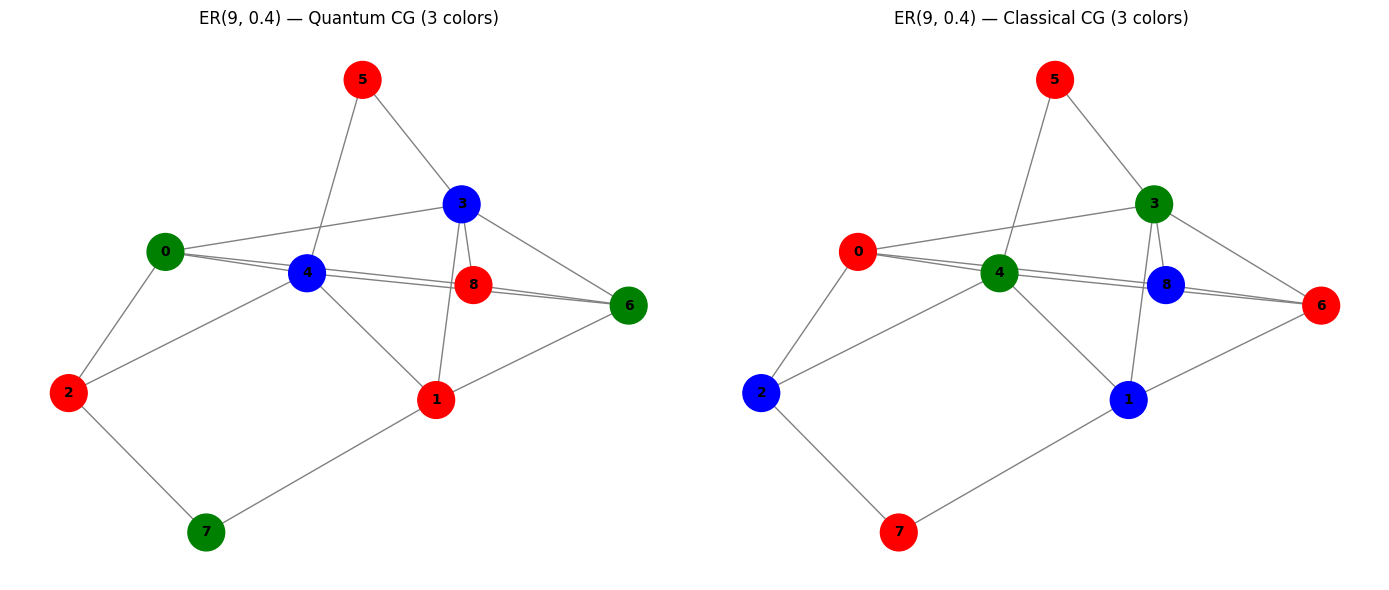

Classical CG: 3 colors
Quantum  CG: 3 colors


In [10]:
G2_quantum = G2.copy()
final_milp_res, final_cols, quantum_coloring = solve_mvcp_column_generation_quantum(
    G2_quantum, graph_name="ER(9, 0.4)",
    direct_ip_address=DIRECT_IP, direct_port=DIRECT_PORT,
)

if final_milp_res and final_milp_res.success:
    print(f"\nQuantum result: χ = {int(round(final_milp_res.fun))}, "
          f"{len(final_cols)} total columns")
    quantum_valid = verify_coloring_solution(G2_quantum, quantum_coloring, "Quantum CG")
    plot_solution_comparison_quantum_classical(
        G2_quantum, quantum_coloring, classical_coloring2, graph_name="ER(9, 0.4)")
    print(f"Classical CG: {len(classical_coloring2)} colors")
    print(f"Quantum  CG: {len(quantum_coloring)} colors")


## Application: Minimizing Antenna Frequencies as a Graph coloring problem

Consider a set of 5G antennas deployed across a city. Each antenna has
a coverage radius, and antennas whose footprints overlap can interfere when
they share the same frequency. The frequency-assignment problem is:

> Assign frequencies to antennas so that **no two antennas within
> interference distance share a frequency**, using as few distinct
> frequencies as possible.

This is precisely **vertex coloring** on the *interference graph*: one
vertex per antenna, an edge between any two antennas closer than a
threshold distance.

The original tutorial uses a real `antenna_Paris.csv` dataset bundled
with the `mis` Pulser package. To keep this notebook self-contained and
free of that dependency, we generate a small synthetic 2-D antenna layout
in a 10 × 10 km box and treat antennas within 2 km as interfering.

Antenna network: 25 nodes, 44 interference edges


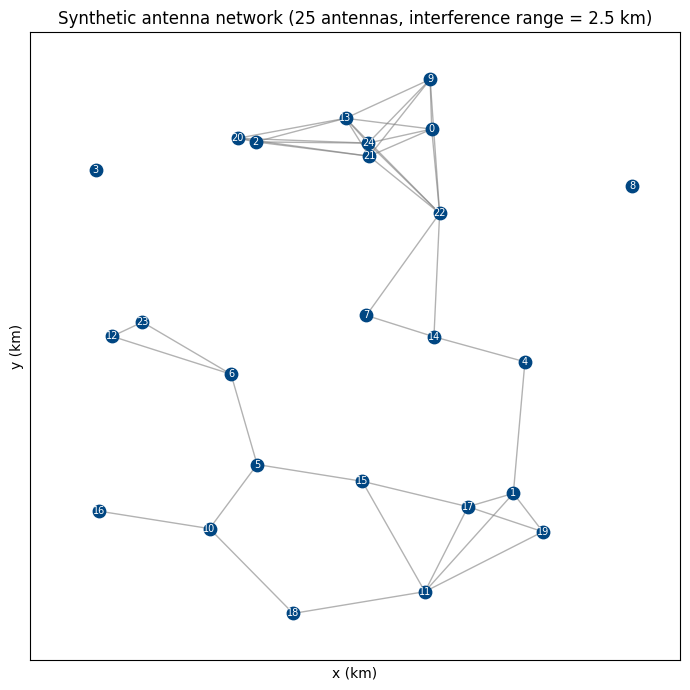

In [11]:
# Synthetic antenna network: 25 antennas uniformly placed in a 10 km box
rng = np.random.default_rng(seed=7)
num_antennas = 25
positions = rng.uniform(0.0, 10.0, size=(num_antennas, 2))
interference_radius = 2.5  # km

# Build the interference graph
G_full = nx.Graph()
for i in range(num_antennas):
    G_full.add_node(i, pos=tuple(positions[i]))
for i in range(num_antennas):
    for j in range(i + 1, num_antennas):
        if np.linalg.norm(positions[i] - positions[j]) <= interference_radius:
            G_full.add_edge(i, j)

print(f"Antenna network: {G_full.number_of_nodes()} nodes, "
      f"{G_full.number_of_edges()} interference edges")
pos_full = nx.get_node_attributes(G_full, 'pos')

plt.figure(figsize=(7, 7))
nx.draw_networkx_nodes(G_full, pos_full, node_size=80, node_color=U.QCI_BLUE)
nx.draw_networkx_edges(G_full, pos_full, width=1, edge_color='gray', alpha=0.6)
nx.draw_networkx_labels(G_full, pos_full, font_size=7, font_color='white')
plt.title(f"Synthetic antenna network ({num_antennas} antennas, "
          f"interference range = {interference_radius} km)")
plt.xlabel("x (km)"); plt.ylabel("y (km)")
plt.axis('equal'); plt.tight_layout(); plt.show()


## Classical CG vs Quantum CG vs Direct MILP

We pick a smaller connected subgraph and benchmark all three approaches on the same instance.

Subgraph H: 12 antennas, 27 edges
Selected: [0, 1, 2, 4, 7, 9, 13, 14, 20, 21, 22, 24]


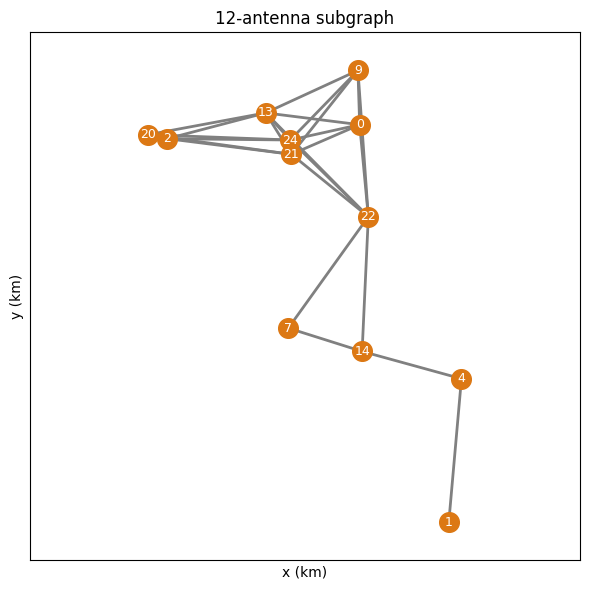

In [12]:
# BFS to extract a connected subgraph of ~12 antennas
def bfs_subgraph(G, seed_node, target_size):
    visited, order, queue = set(), [], [seed_node]
    while queue and len(order) < target_size:
        node = queue.pop(0)
        if node in visited:
            continue
        visited.add(node)
        order.append(node)
        for nb in G.neighbors(node):
            if nb not in visited:
                queue.append(nb)
    return order

# Pick a seed node with high degree so the subgraph is interesting
seed = max(G_full.nodes(), key=lambda v: G_full.degree(v))
selected = bfs_subgraph(G_full, seed, target_size=12)
H = G_full.subgraph(selected).copy()
pos_H = {v: pos_full[v] for v in H.nodes()}

print(f"Subgraph H: {H.number_of_nodes()} antennas, {H.number_of_edges()} edges")
print(f"Selected: {sorted(H.nodes())}")

plt.figure(figsize=(6, 6))
nx.draw_networkx_nodes(H, pos_H, node_size=200, node_color=U.QCI_ORANGE)
nx.draw_networkx_edges(H, pos_H, width=2, edge_color='gray')
nx.draw_networkx_labels(H, pos_H, font_size=9, font_color='white')
plt.title("12-antenna subgraph"); plt.xlabel("x (km)"); plt.ylabel("y (km)")
plt.axis('equal'); plt.tight_layout(); plt.show()


### Quantum CG Solver

In [13]:
H_quantum = H.copy()
print("=" * 60); print("QUANTUM CG ON ANTENNA SUBGRAPH"); print("=" * 60)
t_q = time.monotonic()
q_final, q_cols, q_coloring = solve_mvcp_column_generation_quantum(
    H_quantum, graph_name="Antenna-12",
    direct_ip_address=DIRECT_IP, direct_port=DIRECT_PORT,
)
t_q = time.monotonic() - t_q
print(f"\nQuantum CG took {t_q:.1f}s")
verify_coloring_solution(H_quantum, q_coloring, "Quantum CG")


QUANTUM CG ON ANTENNA SUBGRAPH
Solving MVCP for 12 vertices, 27 edges (Dirac-3 PSP, backend=cloud).
--- Iteration 1 ---
  RMP objective: 12.0000
  Sending PSP to Dirac-3 (cloud)...


2026-05-12 14:16:31 - Dirac allocation balance = 0 s (unmetered)
2026-05-12 14:16:31 - Job submitted: job_id='6a036e7f08442f441bba9014'
2026-05-12 14:16:31 - QUEUED


2026-05-12 14:16:34 - RUNNING


2026-05-12 14:16:54 - COMPLETED


2026-05-12 14:16:57 - Dirac allocation balance = 0 s (unmetered)


...

2026-05-12 14:17:02 - RUNNING


2026-05-12 14:17:15 - COMPLETED


2026-05-12 14:17:17 - Dirac allocation balance = 0 s (unmetered)


  Dirac returned 0 candidate IS in 20.28s
  Max profitable dual sum = 0.0000, added 0 unique new columns (pool size = 24)

  No new profitable columns. Stopping CG.


--- Solving Final RMP as Integer Linear Program ---

Minimum number of colors: 6
  Color 1: [13]
  Color 2: [21]
  Color 3: [22]
  Color 4: [24]
  Color 5: [0, 2, 4, 7]
  Color 6: [1, 9, 14, 20]

Quantum oracle calls: 2
Total API time: 48.31s (avg 24.15s/call)
Avg columns / call: 6.00

Quantum CG took 48.4s
VALID: Quantum CG: 6-coloring


True

### Classical CG Solver

In [14]:
H_classical = H.copy()
print("=" * 60); print("CLASSICAL CG ON ANTENNA SUBGRAPH"); print("=" * 60)
t_c = time.monotonic()
c_final, c_cols, c_coloring = solve_mvcp_column_generation(
    H_classical, graph_name="Antenna-12")
t_c = time.monotonic() - t_c
print(f"\nClassical CG took {t_c:.2f}s")
verify_coloring_solution(H_classical, c_coloring, "Classical CG")


CLASSICAL CG ON ANTENNA SUBGRAPH
Solving MVCP for a graph with 12 vertices and 27 edges.
Initial columns (singleton independent sets): [frozenset({0}), frozenset({1}), frozenset({2}), frozenset({3}), frozenset({4}), frozenset({5}), frozenset({6}), frozenset({7}), frozenset({8}), frozenset({9}), frozenset({10}), frozenset({11})]

--- Iteration 1 ---
  Solving RMP with 12 columns...
  RMP Objective (LP relaxed): 12.0000
  Dual variables: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  Solving PSP (MWIS) classically...
  PSP found IS: {0, 1, 2, 4} (objective = 4.0000)
  Added column. Total: 13
--- Iteration 2 ---
  Solving RMP with 13 columns...
  RMP Objective (LP relaxed): 9.0000
  Dual variables: [ 1.  1.  1.  1. -2.  1.  1.  1.  1.  1.  1.  1.]
  Solving PSP (MWIS) classically...
  PSP found IS: {0, 1, 2, 7} (objective = 4.0000)
  Added column. Total: 14
--- Iteration 3 ---
  Solving RMP with 14 columns...
  RMP Objective (LP relaxed): 9.0000
  Dual variables: [ 1.  1. -2.  1.  1.  1.  1.  1.

True

### Direct MILP Formulation for Antenna Frequency Assignment

While column generation provides an iterative approach to large-scale
coloring, we can also solve the problem directly with a single MILP.

**Variables** $x_{v,c} \in \{0,1\}$ (antenna $v$ is assigned frequency $c$),
$y_c \in \{0,1\}$ (frequency $c$ is used).

**Objective** $\min \sum_c y_c$ (minimise number of frequencies).

**Constraints**

1. Each antenna gets exactly one frequency: $\sum_c x_{v,c} = 1$ for all $v$
2. Adjacent antennas have different frequencies: $x_{u,c} + x_{v,c} \le y_c$ for all $(u,v) \in E$ and all $c$
3. A frequency is "used" only if some antenna uses it: $x_{v,c} \le y_c$

For small graphs this is fast enough to deliver a guaranteed-optimum
baseline against which we can grade both CG approaches.

In [15]:
def solve_mvcp_direct_milp(G, graph_name="Graph", timeout_seconds=300):
    """
    Solve the Minimum Vertex Coloring Problem directly as a single MILP.

    Variables: x[v,c] = 1 iff vertex v gets color c; y[c] = 1 iff color c is used.
    Objective: minimize sum_c y[c].
    """
    start_time = time.time()
    original_nodes = sorted(list(G.nodes()))
    node_to_idx = {node: i for i, node in enumerate(original_nodes)}
    num_vertices = len(original_nodes)
    edges = [(node_to_idx[u], node_to_idx[v]) for u, v in G.edges()]

    print(f"Solving MVCP with direct MILP formulation...")
    print(f"Graph: {num_vertices} vertices, {len(edges)} edges")

    max_colors = num_vertices
    num_x_vars = num_vertices * max_colors
    num_y_vars = max_colors
    total_vars = num_x_vars + num_y_vars
    def x_idx(v, c): return v * max_colors + c
    def y_idx(c): return num_x_vars + c

    c_obj = np.zeros(total_vars)
    for col in range(max_colors):
        c_obj[y_idx(col)] = 1

    constraints = []
    for vertex in range(num_vertices):
        A_row = np.zeros(total_vars)
        for col in range(max_colors):
            A_row[x_idx(vertex, col)] = 1
        constraints.append(LinearConstraint(A_row, 1, 1))
    for u_idx, v_idx in edges:
        for col in range(max_colors):
            A_row = np.zeros(total_vars)
            A_row[x_idx(u_idx, col)] = 1
            A_row[x_idx(v_idx, col)] = 1
            A_row[y_idx(col)] = -1
            constraints.append(LinearConstraint(A_row, -np.inf, 0))
    for vertex in range(num_vertices):
        for col in range(max_colors):
            A_row = np.zeros(total_vars)
            A_row[x_idx(vertex, col)] = 1
            A_row[y_idx(col)] = -1
            constraints.append(LinearConstraint(A_row, -np.inf, 0))

    bounds = Bounds(lb=0, ub=1)
    integrality = np.ones(total_vars, dtype=int)

    print(f"MILP: {len(constraints)} constraints, {total_vars} variables")
    try:
        milp_result = milp(c=c_obj, constraints=constraints, bounds=bounds,
                           integrality=integrality,
                           options={'time_limit': timeout_seconds})
    except Exception as e:
        print(f"MILP failed: {e}")
        return None, None, []

    solve_time = time.time() - start_time
    if milp_result.success:
        optimal_colors = int(round(milp_result.fun))
        print(f"SUCCESS: optimal coloring = {optimal_colors} colors  ({solve_time:.2f}s)")
        coloring_solution = []
        used_colors = [col for col in range(max_colors)
                       if milp_result.x[y_idx(col)] > 0.5]
        for col in used_colors:
            color_set = {original_nodes[v] for v in range(num_vertices)
                         if milp_result.x[x_idx(v, col)] > 0.5}
            if color_set:
                coloring_solution.append(frozenset(color_set))
                print(f"  Color {col}: {sorted(color_set)}")
        return milp_result, None, coloring_solution
    else:
        print(f"FAILED: {milp_result.message}  ({solve_time:.2f}s)")
        return milp_result, None, []


In [16]:
H_direct = H.copy()
print("=" * 60); print("DIRECT MILP ON ANTENNA SUBGRAPH"); print("=" * 60)
direct_milp_result, _, direct_coloring = solve_mvcp_direct_milp(
    H_direct, graph_name="Antenna-12", timeout_seconds=60)
if direct_milp_result and direct_milp_result.success:
    verify_coloring_solution(H_direct, direct_coloring, "Direct MILP")


DIRECT MILP ON ANTENNA SUBGRAPH
Solving MVCP with direct MILP formulation...
Graph: 12 vertices, 27 edges
MILP: 480 constraints, 156 variables
SUCCESS: optimal coloring = 6 colors  (0.04s)
  Color 0: [4, 7, 21]
  Color 1: [0, 14, 20]
  Color 4: [13]
  Color 7: [9]
  Color 8: [1, 2, 22]
  Color 10: [24]
VALID: Direct MILP: 6-coloring


### Classical Column Generation vs Quantum CG vs Direct MILP Comparison

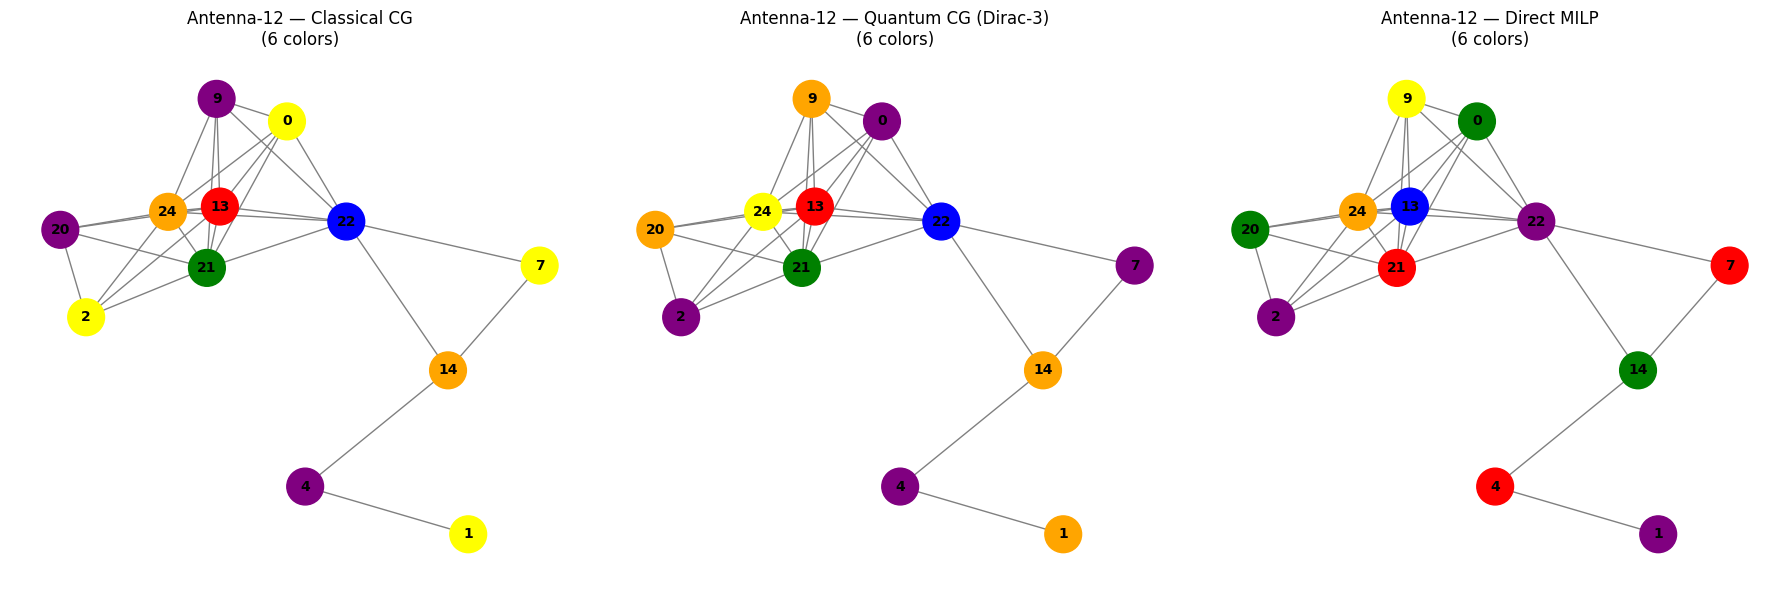

In [17]:
def plot_solution_comparison_3way(G, classical_solution, quantum_solution,
                                  direct_solution, graph_name="Graph"):
    pos = nx.spring_layout(G, seed=42, k=1.5, iterations=100)
    palette = ['red','green','blue','yellow','purple','orange','cyan','magenta',
               'lime','pink','teal','brown']
    def cm(sol):
        out = {}
        for k, cs in enumerate(sol or []):
            for n in cs:
                out[n] = palette[k % len(palette)]
        return out
    ccm, qcm, dcm = cm(classical_solution), cm(quantum_solution), cm(direct_solution)
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    for ax, sol, cmap, label in zip(
        axes,
        [classical_solution, quantum_solution, direct_solution],
        [ccm, qcm, dcm],
        ["Classical CG", "Quantum CG (Dirac-3)", "Direct MILP"],
    ):
        nlist = list(G.nodes())
        colors = [cmap.get(n, 'lightgray') for n in nlist]
        nx.draw(G, pos, ax=ax, with_labels=True, node_color=colors,
                node_size=700, font_size=10, font_weight='bold', edge_color='gray')
        ax.set_title(f"{graph_name} — {label}\n"
                     f"({len(sol) if sol else 'failed'} colors)")
    plt.tight_layout(); plt.show()

plot_solution_comparison_3way(H, c_coloring, q_coloring, direct_coloring,
                              graph_name="Antenna-12")


In [18]:
import pandas as pd

direct_chi = (len(direct_coloring) if (direct_milp_result and direct_milp_result.success)
              else None)
rows = [
    {"method": "Classical CG", "χ": len(c_coloring), "runtime_s": round(t_c, 2),
     "columns_in_pool": len(c_cols), "optimality": "heuristic"},
    {"method": "Quantum CG (Dirac-3)", "χ": len(q_coloring), "runtime_s": round(t_q, 2),
     "columns_in_pool": len(q_cols), "optimality": "heuristic"},
    {"method": "Direct MILP", "χ": direct_chi or "—", "runtime_s": "—",
     "columns_in_pool": "—", "optimality": "optimal"},
]
df = pd.DataFrame(rows)
print(df.to_string(index=False))


              method  χ runtime_s columns_in_pool optimality
        Classical CG  6      0.02              19  heuristic
Quantum CG (Dirac-3)  6     48.35              24  heuristic
         Direct MILP  6         —               —    optimal


### Key Lessons

We have walked end-to-end through the column-generation algorithm of
Wesley da Silva Coelho et al.
([arXiv:2301.02637](https://arxiv.org/abs/2301.02637)), implemented in
plain `scipy` for both classical and quantum variants. The quantum
variant uses QCi's Dirac-3 photonic device to sample the **Motzkin-Straus
quadratic program** for the pricing sub-problem; a single device call
yields multiple independent sets per iteration, so the column pool grows
faster than classical CG even with a noisy quantum solver.

On the synthetic antenna application both CG approaches recover the same
chromatic number as the direct MILP — the test instance is small enough
that no optimality gap remains. The interesting regime (where direct MILP
becomes intractable but CG still scales) lies at $n \gtrsim 50$ vertices;
the companion notebooks `02b` / `03b` walk through that regime with the
same primitives.

For the underlying machinery (replay vs cloud vs direct backend, run
capture/replay, full pipeline comparisons against Hexaly and B&P) see
`notebooks/_demo_utils.py` and `notebooks/03b_application_demo_realtime.ipynb`.